In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv("titanic.csv")
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())

Shape: (891, 12)
Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [2]:
# Select 4 features + target
df = df[["Pclass", "Sex", "Age", "Fare", "Survived"]]

# Fill missing Age with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Encode Sex: female=0, male=1
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

# Features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (623, 4) | Test: (268, 4)


Accuracy: 0.7947761194029851

              precision    recall  f1-score   support

Not Survived       0.81      0.85      0.83       157
    Survived       0.77      0.71      0.74       111

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.79       268
weighted avg       0.79      0.79      0.79       268



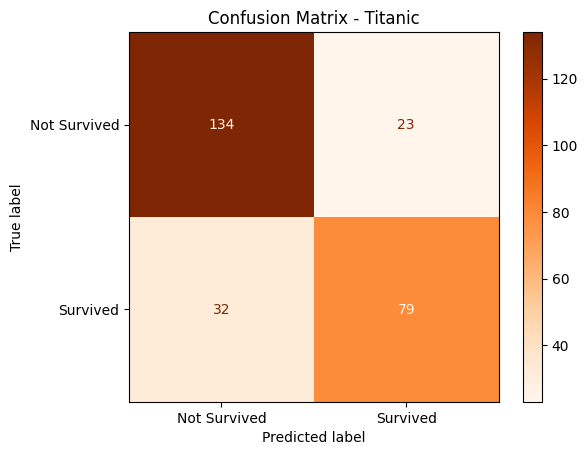

Prediction: Survived


In [3]:
# Train model
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
disp.plot(cmap="Oranges")
plt.title("Confusion Matrix - Titanic")
plt.show()

# External Prediction
new_passenger = [[3, 0, 25, 7.5]]
new_df = pd.DataFrame(new_passenger, columns=X.columns)
result = log_reg.predict(new_df)[0]
print("Prediction:", "Survived" if result == 1 else "Not Survived")